# tactical-asset-allocation-lstm

**Author:** Sana Ur Rehman  
**Profession:** Data Scientist  
**Created:** 2026  

---

## License

This project is licensed under the **MIT License**. 

You are free to use, modify, distribute, and build upon this work for both commercial and non-commercial purposes, provided you give appropriate **credit** to the original author. For the full legal text and conditions, please refer to the `LICENSE` file included in this project's repository.

---

## Citation

If you reference or build upon this project, please provide appropriate credit.

For formal citation information, please see the project's `README.md` and `CITATION.cff` files.

# Step 3 — Multi-output LSTM model

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Load Step 1 saved splits
ret_train = pd.read_csv("data/returns_train.csv", index_col=0, parse_dates=True)
ret_val   = pd.read_csv("data/returns_val.csv",   index_col=0, parse_dates=True)
ret_test  = pd.read_csv("data/returns_test.csv",  index_col=0, parse_dates=True)

y_train = pd.read_csv("data/target_train.csv", index_col=0, parse_dates=True)
y_val   = pd.read_csv("data/target_val.csv",   index_col=0, parse_dates=True)
y_test  = pd.read_csv("data/target_test.csv",  index_col=0, parse_dates=True)

assets = list(ret_train.columns)
assets

C:\Users\Yahya\AppData\Roaming\Python\Python313\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\Yahya\AppData\Roaming\Python\Python313\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\Yahya\AppData\Roaming\Python\Python313\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/resource_handle.proto. Please 

['Equity (SPY)',
 'Long Treasuries (TLT)',
 'Short Treasuries (SHY)',
 'Gold (GLD)',
 'Oil (DBO)']

Feature engineering

In [2]:
LOOKBACK = 60
USE_ROLLING = True

def build_features(returns_df):
    X = returns_df.copy()
    if USE_ROLLING:
        for w in [5, 21, 63]:
            X = X.join(returns_df.rolling(w).mean().add_suffix(f"_mean{w}"))
            X = X.join(returns_df.rolling(w).std().add_suffix(f"_vol{w}"))
    X = X.dropna()
    return X

X_train_df = build_features(ret_train)
X_val_df   = build_features(ret_val)
X_test_df  = build_features(ret_test)

# Align Y (multi-output) to the feature indices
Y_train_df = y_train.loc[X_train_df.index, assets]
Y_val_df   = y_val.loc[X_val_df.index, assets]
Y_test_df  = y_test.loc[X_test_df.index, assets]

X_train_df.shape, Y_train_df.shape, X_val_df.shape, Y_val_df.shape, X_test_df.shape, Y_test_df.shape

((1699, 35), (1699, 5), (189, 35), (189, 5), (1172, 35), (1172, 5))

Scale inputs (fit scaler on train only)

In [3]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_df)
X_val_scaled   = scaler.transform(X_val_df)
X_test_scaled  = scaler.transform(X_test_df)

Build multi-output sequences (X is 3D, Y is 2D)

In [4]:
def make_multi_sequences(X_scaled, Y_df, lookback):
    """
    X_scaled: (T, n_features)
    Y_df:     (T, n_outputs=5), aligned with X
    Returns:
      X_seq: (N, lookback, n_features)
      Y_seq: (N, n_outputs)
      idx:   timestamps for each label row
    """
    X_arr = X_scaled.astype(np.float32)
    Y_arr = Y_df.values.astype(np.float32)

    X_seq, Y_seq, idx = [], [], []
    for t in range(lookback, len(X_arr)):
        X_seq.append(X_arr[t-lookback:t, :])
        Y_seq.append(Y_arr[t, :])
        idx.append(Y_df.index[t])

    return np.array(X_seq), np.array(Y_seq), pd.to_datetime(idx)

Xtr, Ytr, idx_tr = make_multi_sequences(X_train_scaled, Y_train_df, LOOKBACK)
Xva, Yva, idx_va = make_multi_sequences(X_val_scaled,   Y_val_df,   LOOKBACK)
Xte, Yte, idx_te = make_multi_sequences(X_test_scaled,  Y_test_df,  LOOKBACK)

Xtr.shape, Ytr.shape, Xte.shape, Yte.shape

((1639, 60, 35), (1639, 5), (1112, 60, 35), (1112, 5))

Build the multi-output LSTM model

In [5]:
# Regularized multi-output LSTM
from tensorflow.keras import regularizers

def build_multi_output_lstm_reg(
    n_features,
    lookback,
    n_outputs=5,
    lr=1e-3,
    lstm_units=32,      # smaller LSTM (was 64)
    dropout=0.4,        # higher dropout (was 0.2)
    l2_lambda=1e-4      # L2 regularization strength
):
    inp = layers.Input(shape=(lookback, n_features))

    x = layers.LSTM(
        lstm_units,
        return_sequences=False,
        kernel_regularizer=regularizers.l2(l2_lambda),
        recurrent_regularizer=regularizers.l2(l2_lambda),
        bias_regularizer=regularizers.l2(l2_lambda)
    )(inp)

    x = layers.Dropout(dropout)(x)

    x = layers.Dense(
        64,
        activation="relu",
        kernel_regularizer=regularizers.l2(l2_lambda),
        bias_regularizer=regularizers.l2(l2_lambda)
    )(x)

    x = layers.Dense(
        32,
        activation="relu",
        kernel_regularizer=regularizers.l2(l2_lambda),
        bias_regularizer=regularizers.l2(l2_lambda)
    )(x)

    out = layers.Dense(n_outputs, name="y_hat")(x)

    model = keras.Model(inputs=inp, outputs=out)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="mse"
    )
    return model

In [6]:
def directional_accuracy_eps(y_true, y_pred, eps=0.0):
    # classify predicted direction: +1 if >eps else -1
    pred_dir = np.where(y_pred > eps, 1, -1)
    true_dir = np.where(y_true > 0, 1, -1)
    return (pred_dir == true_dir).mean()

In [7]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def metrics_multi(y_true, y_pred, asset_names):
    rows = []
    for j, a in enumerate(asset_names):
        yt = y_true[:, j]
        yp = y_pred[:, j]
        mse = mean_squared_error(yt, yp)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(yt, yp)
        r2 = r2_score(yt, yp)
        # Calculate directional accuracy
        da = directional_accuracy_eps(yt, yp, eps=0.0)
        rows.append([a, mse, rmse, mae, r2, da])
    
    return pd.DataFrame(rows, columns=["Asset", "MSE", "RMSE", "MAE", "R2", "DirectionalAcc"]).set_index("Asset")

Regularized Multi-output Model

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 60, 35)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │         8,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ y_hat (Dense)                   │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,061 (51.02 KB)

 Trainable params: 13,061 (51.02 KB)

 Non-trainable params: 0 (0.00 B)

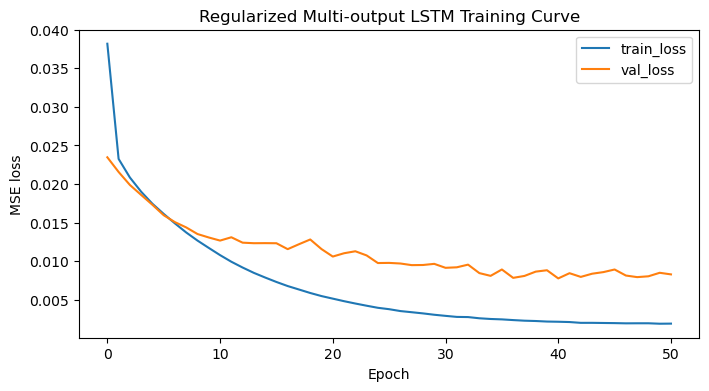

Regularized model — Test metrics:


,MSE,RMSE,MAE,R2,DirectionalAcc
Asset,,,,,
Short Treasuries (SHY),0.000050,0.007067,0.005126,-0.709783,0.602518
Long Treasuries (TLT),0.002697,0.051932,0.041147,-0.125171,0.561151
Gold (GLD),0.002716,0.052116,0.042141,-0.588848,0.533273
Equity (SPY),0.004378,0.066167,0.047020,-0.063799,0.573741
Oil (DBO),0.021431,0.146394,0.117563,-0.648230,0.540468


In [8]:
# Build regularized model
multi_model_reg = build_multi_output_lstm_reg(
    n_features=Xtr.shape[-1],
    lookback=LOOKBACK,
    n_outputs=len(assets),
    lr=1e-3,
    lstm_units=32,
    dropout=0.4,
    l2_lambda=1e-4
)

multi_model_reg.summary()

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-5)
]

hist_multi_reg = multi_model_reg.fit(
    Xtr, Ytr,
    validation_data=(Xva, Yva),
    epochs=120,
    batch_size=32,
    verbose=0,
    callbacks=callbacks
)

plt.figure(figsize=(8,4))
plt.plot(hist_multi_reg.history["loss"], label="train_loss")
plt.plot(hist_multi_reg.history["val_loss"], label="val_loss")
plt.title("Regularized Multi-output LSTM Training Curve")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.legend()
plt.show()

# Predictions + metrics
pred_te_reg = multi_model_reg.predict(Xte, verbose=0)
metrics_test_reg = metrics_multi(Yte, pred_te_reg, assets)

print("Regularized model — Test metrics:")
display(metrics_test_reg.sort_values("RMSE"))

In [9]:
pred_tr_reg = multi_model_reg.predict(Xtr, verbose=0)
pred_va_reg = multi_model_reg.predict(Xva, verbose=0)
pred_te_reg = multi_model_reg.predict(Xte, verbose=0)

metrics_train_reg = metrics_multi(Ytr, pred_tr_reg, assets)
metrics_val_reg   = metrics_multi(Yva, pred_va_reg, assets)
metrics_test_reg  = metrics_multi(Yte, pred_te_reg, assets)

print("REG Train metrics:")
display(metrics_train_reg.sort_values("RMSE"))
print("REG Val metrics:")
display(metrics_val_reg.sort_values("RMSE"))
print("REG Test metrics:")
display(metrics_test_reg.sort_values("RMSE"))

REG Train metrics:


,MSE,RMSE,MAE,R2,DirectionalAcc
Asset,,,,,
Short Treasuries (SHY),0.000012,0.003412,0.002673,-1.520755,0.535692
Equity (SPY),0.000815,0.028554,0.021486,0.442382,0.794387
Long Treasuries (TLT),0.000900,0.030004,0.023844,0.482515,0.735204
Gold (GLD),0.001286,0.035858,0.028044,0.530445,0.771202
Oil (DBO),0.001760,0.041950,0.032486,0.789873,0.801098


REG Val metrics:


,MSE,RMSE,MAE,R2,DirectionalAcc
Asset,,,,,
Short Treasuries (SHY),0.000012,0.003442,0.002752,-2.733486,0.697674
Equity (SPY),0.001055,0.032480,0.029819,-2.106663,0.503876
Long Treasuries (TLT),0.001096,0.033113,0.028145,-1.493763,0.589147
Gold (GLD),0.002390,0.048888,0.038937,-1.370998,0.348837
Oil (DBO),0.029610,0.172075,0.158258,-17.698433,0.100775


REG Test metrics:


,MSE,RMSE,MAE,R2,DirectionalAcc
Asset,,,,,
Short Treasuries (SHY),0.000050,0.007067,0.005126,-0.709783,0.602518
Long Treasuries (TLT),0.002697,0.051932,0.041147,-0.125171,0.561151
Gold (GLD),0.002716,0.052116,0.042141,-0.588848,0.533273
Equity (SPY),0.004378,0.066167,0.047020,-0.063799,0.573741
Oil (DBO),0.021431,0.146394,0.117563,-0.648230,0.540468


Overall (averaged) summary

In [10]:
overall_reg = pd.DataFrame({
    "Train": metrics_train_reg.mean(numeric_only=True),
    "Val":   metrics_val_reg.mean(numeric_only=True),
    "Test":  metrics_test_reg.mean(numeric_only=True)
})
overall_reg

,Train,Val,Test
MSE,0.000955,0.006833,0.006254
RMSE,0.027956,0.058000,0.064735
MAE,0.021707,0.051582,0.050599
R2,0.144892,-5.080669,-0.427166
DirectionalAcc,0.727517,0.448062,0.562230


In [11]:
# Upgrade A: Naive baselines for context (predict 0 and predict train-mean)

def baseline_metrics(Y_true, Y_pred, asset_names):
    rows = []
    for j, a in enumerate(asset_names):
        yt = Y_true[:, j]
        yp = Y_pred[:, j]
        mse = mean_squared_error(yt, yp)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(yt, yp)
        r2 = r2_score(yt, yp)
        da = directional_accuracy_eps(yt, yp, eps=0.0)
        rows.append([a, mse, rmse, mae, r2, da])
    return pd.DataFrame(rows, columns=["Asset","MSE","RMSE","MAE","R2","DirectionalAcc"]).set_index("Asset")

# 1) Baseline 1: predict 0 for all assets
pred0_te = np.zeros_like(Yte)
base0_test = baseline_metrics(Yte, pred0_te, assets)

# 2) Baseline 2: predict TRAIN mean (per asset) for all timesteps
train_mean = Ytr.mean(axis=0)  # shape (5,)
pred_mean_te = np.tile(train_mean, (Yte.shape[0], 1))
basemean_test = baseline_metrics(Yte, pred_mean_te, assets)

print("Baseline (predict 0) — Test:")
display(base0_test.sort_values("RMSE"))

print("Baseline (predict train-mean) — Test:")
display(basemean_test.sort_values("RMSE"))

# Compare model vs baselines (Test RMSE + R2)
compare = pd.DataFrame({
    "Model_RMSE": metrics_test_reg["RMSE"],
    "Base0_RMSE": base0_test["RMSE"],
    "Mean_RMSE":  basemean_test["RMSE"],
    "Model_R2":   metrics_test_reg["R2"],
    "Base0_R2":   base0_test["R2"],
    "Mean_R2":    basemean_test["R2"],
}).sort_values("Model_RMSE")

compare

Baseline (predict 0) — Test:


,MSE,RMSE,MAE,R2,DirectionalAcc
Asset,,,,,
Short Treasuries (SHY),0.000030,0.005450,0.003688,-0.016869,0.410072
Gold (GLD),0.001772,0.042094,0.033091,-0.036514,0.458633
Long Treasuries (TLT),0.002399,0.048975,0.037575,-0.000699,0.526079
Equity (SPY),0.004204,0.064836,0.047948,-0.021433,0.320144
Oil (DBO),0.013030,0.114150,0.088716,-0.002126,0.410971


Baseline (predict train-mean) — Test:


,MSE,RMSE,MAE,R2,DirectionalAcc
Asset,,,,,
Short Treasuries (SHY),0.000029,0.005406,0.003650,-0.000304,0.589928
Gold (GLD),0.001777,0.042155,0.033118,-0.039521,0.458633
Long Treasuries (TLT),0.002447,0.049466,0.038233,-0.020842,0.473921
Equity (SPY),0.004131,0.064274,0.044303,-0.003800,0.679856
Oil (DBO),0.013395,0.115735,0.092031,-0.030149,0.410971


,Model_RMSE,Base0_RMSE,Mean_RMSE,Model_R2,Base0_R2,Mean_R2
Asset,,,,,,
Short Treasuries (SHY),0.007067,0.005450,0.005406,-0.709783,-0.016869,-0.000304
Long Treasuries (TLT),0.051932,0.048975,0.049466,-0.125171,-0.000699,-0.020842
Gold (GLD),0.052116,0.042094,0.042155,-0.588848,-0.036514,-0.039521
Equity (SPY),0.066167,0.064836,0.064274,-0.063799,-0.021433,-0.003800
Oil (DBO),0.146394,0.114150,0.115735,-0.648230,-0.002126,-0.030149


In [12]:
os.makedirs("outputs", exist_ok=True)

# Save REG predictions on test set
preds_multi_test_reg = pd.DataFrame(pred_te_reg, index=idx_te, columns=assets)
actuals_multi_test_reg = pd.DataFrame(Yte, index=idx_te, columns=assets)

preds_multi_test_reg.to_csv("outputs/step3_multi_output_predictions_REG.csv")
actuals_multi_test_reg.to_csv("outputs/step3_multi_output_actuals_REG.csv")

print("Saved:")
print(" - outputs/step3_multi_output_predictions_REG.csv")
print(" - outputs/step3_multi_output_actuals_REG.csv")

Saved:
 - outputs/step3_multi_output_predictions_REG.csv
 - outputs/step3_multi_output_actuals_REG.csv


Plot predicted vs actual

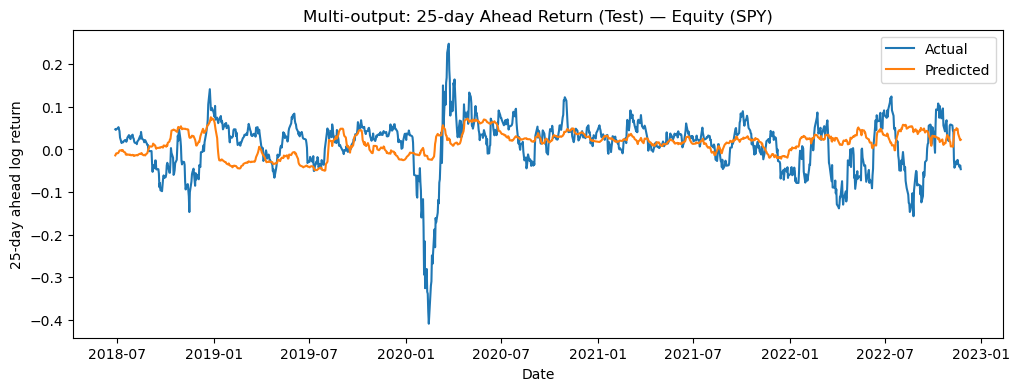

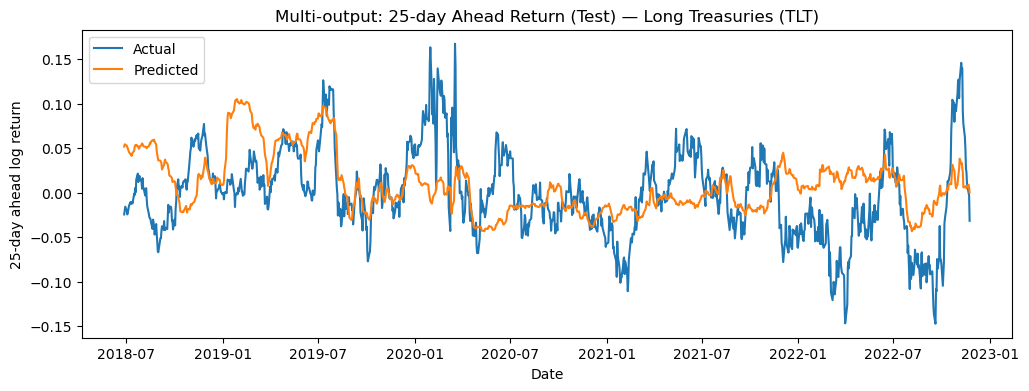

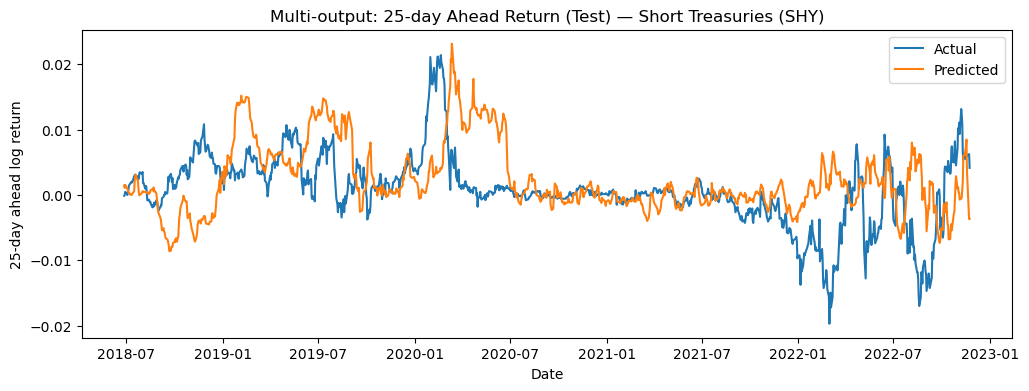

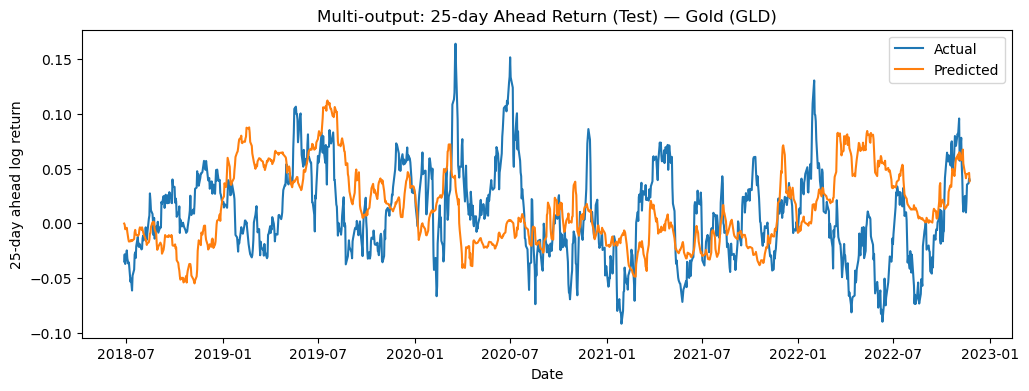

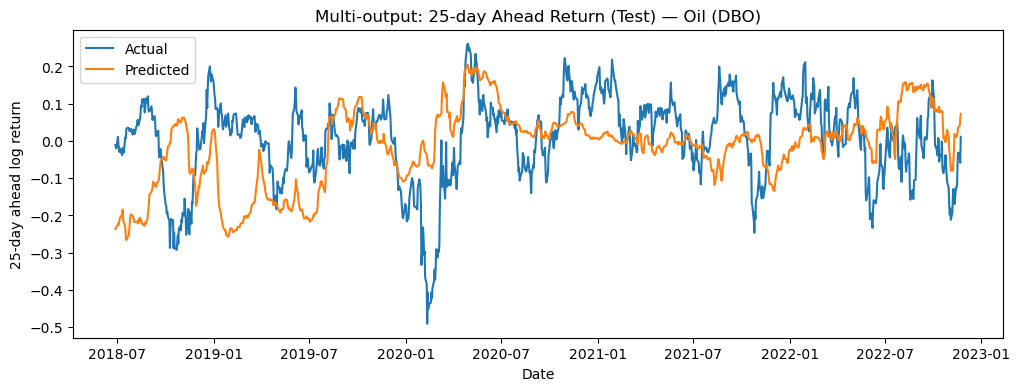

In [13]:
def plot_pred_vs_actual_df(pred_df, actual_df, asset):
    plt.figure(figsize=(12,4))
    plt.plot(actual_df.index, actual_df[asset].values, label="Actual")
    plt.plot(pred_df.index, pred_df[asset].values, label="Predicted")
    plt.title(f"Multi-output: 25-day Ahead Return (Test) — {asset}")
    plt.xlabel("Date")
    plt.ylabel("25-day ahead log return")
    plt.legend()
    plt.show()

preds_multi_test = pd.read_csv("outputs/step3_multi_output_predictions_REG.csv", index_col=0, parse_dates=True)
actuals_multi_test = pd.read_csv("outputs/step3_multi_output_actuals_REG.csv", index_col=0, parse_dates=True)

for a in assets:
    plot_pred_vs_actual_df(preds_multi_test, actuals_multi_test, a)

Step 3c–3d — Strategy + Backtest using multi-output predictions

Rebalance index

In [14]:
H = 25
rebalance_idx = preds_multi_test.index[::H]
rebalance_idx[:5], len(rebalance_idx)

(DatetimeIndex(['2018-06-27', '2018-08-02', '2018-09-07', '2018-10-12',
                '2018-11-16'],
               dtype='datetime64[ns]', freq=None),
 45)

Weights, turnover, gross/net returns (multi-output)

In [15]:
def build_long_short_weights(pred_row, n_long=2, n_short=2):
    ranked = pred_row.sort_values(ascending=False)
    longs = ranked.index[:n_long]
    shorts = ranked.index[-n_short:]

    w = pd.Series(0.0, index=pred_row.index)
    w.loc[longs] =  1.0 / n_long
    w.loc[shorts] = -1.0 / n_short
    return w

weights_multi = pd.DataFrame(index=rebalance_idx, columns=assets, dtype=float)
for dt in rebalance_idx:
    weights_multi.loc[dt] = build_long_short_weights(preds_multi_test.loc[dt], 2, 2)

# Turnover + transaction costs
tc = 0.001
w_diff = weights_multi.diff().abs()
turnover_multi = 0.5 * w_diff.sum(axis=1)
turnover_multi.iloc[0] = 0.5 * weights_multi.iloc[0].abs().sum()

# Backtest using realized forward 25d returns
multi_gross = []
multi_net = []

for dt in rebalance_idx:
    w = weights_multi.loc[dt].astype(float)
    realized = actuals_multi_test.loc[dt].astype(float)

    r_g = float((w * realized).sum())
    cost = tc * float(turnover_multi.loc[dt])
    r_n = r_g - cost

    multi_gross.append(r_g)
    multi_net.append(r_n)

multi_gross = pd.Series(multi_gross, index=rebalance_idx, name="multi_gross_25d_logret")
multi_net   = pd.Series(multi_net,   index=rebalance_idx, name="multi_net_25d_logret")

multi_gross.head(), multi_net.head()

(2018-06-27   -0.030200
 2018-08-02   -0.014367
 2018-09-07   -0.077648
 2018-10-12   -0.115181
 2018-11-16    0.053658
 Name: multi_gross_25d_logret, dtype: float64,
 2018-06-27   -0.031200
 2018-08-02   -0.014367
 2018-09-07   -0.078648
 2018-10-12   -0.116181
 2018-11-16    0.052658
 Name: multi_net_25d_logret, dtype: float64)

Benchmark (EW buy-and-hold) at same 25-day frequency

In [16]:
ew_w = pd.Series(1/len(assets), index=assets)

bench_25d = []
for dt in rebalance_idx:
    realized = actuals_multi_test.loc[dt].astype(float)
    bench_25d.append(float((ew_w * realized).sum()))
bench_25d = pd.Series(bench_25d, index=rebalance_idx, name="ew_bh_25d_logret")

bench_25d.head()

2018-06-27   -0.004712
2018-08-02    0.006789
2018-09-07    0.001152
2018-10-12   -0.042187
2018-11-16   -0.040304
Name: ew_bh_25d_logret, dtype: float64

Compare vs Step 2 strategy

In [17]:
# Load Step 2 predictions/actuals and reconstruct Step 2 net series
preds_s2 = pd.read_csv("outputs/step2_single_output_predictions.csv", index_col=0, parse_dates=True)
acts_s2  = pd.read_csv("outputs/step2_single_output_actuals.csv", index_col=0, parse_dates=True)

preds_s2.columns = [c.replace("pred_", "") for c in preds_s2.columns]
acts_s2.columns  = [c.replace("actual_", "") for c in acts_s2.columns]

common_idx = preds_s2.index.intersection(acts_s2.index)
preds_s2 = preds_s2.loc[common_idx].sort_index()
acts_s2  = acts_s2.loc[common_idx].sort_index()

rebalance_s2 = preds_s2.index[::H]

weights_s2 = pd.DataFrame(index=rebalance_s2, columns=assets, dtype=float)
for dt in rebalance_s2:
    weights_s2.loc[dt] = build_long_short_weights(preds_s2.loc[dt], 2, 2)

w_diff_s2 = weights_s2.diff().abs()
turnover_s2 = 0.5 * w_diff_s2.sum(axis=1)
turnover_s2.iloc[0] = 0.5 * weights_s2.iloc[0].abs().sum()

s2_net = []
for dt in rebalance_s2:
    w = weights_s2.loc[dt].astype(float)
    realized = acts_s2.loc[dt].astype(float)
    r_g = float((w * realized).sum())
    cost = tc * float(turnover_s2.loc[dt])
    s2_net.append(r_g - cost)

s2_net = pd.Series(s2_net, index=rebalance_s2, name="single_net_25d_logret")

# Align indices for plotting comparison (intersection)
common_reb = multi_net.index.intersection(s2_net.index).intersection(bench_25d.index)
multi_net_al = multi_net.loc[common_reb]
s2_net_al = s2_net.loc[common_reb]
bench_al = bench_25d.loc[common_reb]

len(common_reb), common_reb[:3]

(45,
 DatetimeIndex(['2018-06-27', '2018-08-02', '2018-09-07'], dtype='datetime64[ns]', freq=None))

Performance stats + equity curves (3-way comparison)

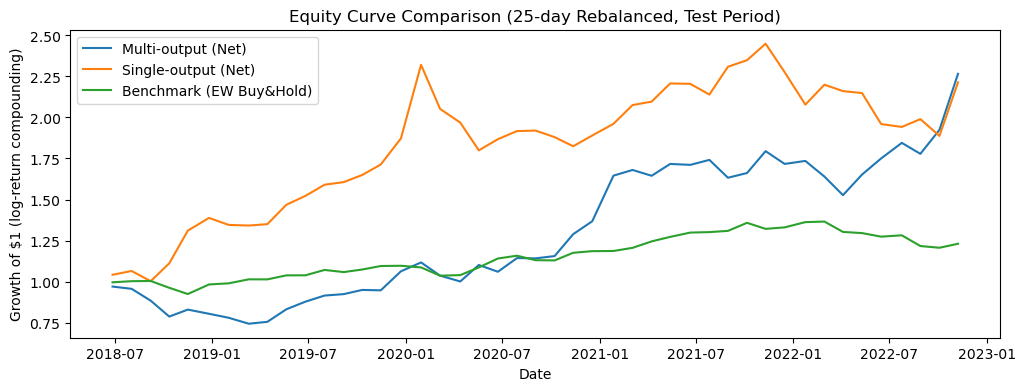

In [18]:
def perf_stats(r_25d, periods_per_year=252/25):
    r = r_25d.dropna()
    mean = r.mean() * periods_per_year
    vol  = r.std()  * np.sqrt(periods_per_year)
    sharpe = mean / vol if vol > 0 else np.nan
    eq = np.exp(r.cumsum())
    peak = eq.cummax()
    dd = (eq / peak) - 1.0
    mdd = dd.min()
    return pd.Series({
        "ann_mean_log": mean,
        "ann_vol": vol,
        "sharpe_(rf=0)": sharpe,
        "max_drawdown": mdd,
        "n_periods": len(r)
    })

stats_step3 = pd.DataFrame({
    "Multi-output (Net)": perf_stats(multi_net_al),
    "Single-output (Net)": perf_stats(s2_net_al),
    "Benchmark (EW B/H)": perf_stats(bench_al)
})
stats_step3

eq_multi = np.exp(multi_net_al.cumsum())
eq_s2    = np.exp(s2_net_al.cumsum())
eq_bench = np.exp(bench_al.cumsum())

plt.figure(figsize=(12,4))
plt.plot(eq_multi.index, eq_multi.values, label="Multi-output (Net)")
plt.plot(eq_s2.index, eq_s2.values, label="Single-output (Net)")
plt.plot(eq_bench.index, eq_bench.values, label="Benchmark (EW Buy&Hold)")
plt.title("Equity Curve Comparison (25-day Rebalanced, Test Period)")
plt.xlabel("Date")
plt.ylabel("Growth of $1 (log-return compounding)")
plt.legend()
plt.show()

Diagnostics: turnover + selection frequencies (multi-output)

In [19]:
pd.DataFrame({
    "avg_turnover": [turnover_multi.mean()],
    "total_cost_(sum tc*turnover)": [(tc * turnover_multi).sum()],
    "tc": [tc],
    "n_rebalances": [len(turnover_multi)]
})

long_counts = pd.Series(0, index=assets, dtype=int)
short_counts = pd.Series(0, index=assets, dtype=int)

for dt in weights_multi.index:
    w = weights_multi.loc[dt]
    long_counts[w > 0] += 1
    short_counts[w < 0] += 1

alloc_multi = pd.DataFrame({"long_count": long_counts, "short_count": short_counts}).sort_values("long_count", ascending=False)
alloc_multi

,long_count,short_count
Equity (SPY),27,10
Oil (DBO),22,22
Long Treasuries (TLT),19,23
Gold (GLD),16,19
Short Treasuries (SHY),6,16


In [20]:
display(metrics_test_reg.sort_values("RMSE"))

,MSE,RMSE,MAE,R2,DirectionalAcc
Asset,,,,,
Short Treasuries (SHY),0.000050,0.007067,0.005126,-0.709783,0.602518
Long Treasuries (TLT),0.002697,0.051932,0.041147,-0.125171,0.561151
Gold (GLD),0.002716,0.052116,0.042141,-0.588848,0.533273
Equity (SPY),0.004378,0.066167,0.047020,-0.063799,0.573741
Oil (DBO),0.021431,0.146394,0.117563,-0.648230,0.540468


In [21]:
os.makedirs("outputs", exist_ok=True)

preds_multi_test_reg = pd.DataFrame(pred_te_reg, index=idx_te, columns=assets)
preds_multi_test_reg.to_csv("outputs/step3_multi_output_predictions_REG.csv")

actuals_multi_test = pd.DataFrame(Yte, index=idx_te, columns=assets)
actuals_multi_test.to_csv("outputs/step3_multi_output_actuals_REG.csv")

print("Saved:")
print(" - outputs/step3_multi_output_predictions_REG.csv")
print(" - outputs/step3_multi_output_actuals_REG.csv")

Saved:
 - outputs/step3_multi_output_predictions_REG.csv
 - outputs/step3_multi_output_actuals_REG.csv


Extras

Strategy Backtest (Regularized Multi-output)

In [ ]:
preds_multi_test_reg = pd.read_csv("outputs/step3_multi_output_predictions_REG.csv", index_col=0, parse_dates=True)
actuals_multi_test   = pd.read_csv("outputs/step3_multi_output_actuals_REG.csv", index_col=0, parse_dates=True)

# reuse Step 3c–3d strategy cells (weights, turnover, net returns, equity curve)

table 15

In [ ]:
# ===== Table 15: Step 3 Strategy Performance (Net) vs Step 2 and Benchmark =====

stats_step3 = pd.DataFrame({
 "Multi-output (Net)": perf_stats(multi_net_al),
 "Single-output (Net)": perf_stats(s2_net_al),
 "Benchmark (EW B/H)": perf_stats(bench_al)
})

table15 = stats_step3.loc[["ann_mean_log","ann_vol","sharpe_(rf=0)","max_drawdown"]].T.copy()

table15 = table15.rename(columns={
    "ann_mean_log": "Annualized Mean (Log)",
    "ann_vol": "Annualized Vol",
    "sharpe_(rf=0)": "Sharpe Ratio",
    "max_drawdown": "Max Drawdown"
})

# Optional: format drawdown as % and round
table15["Max Drawdown"] = (table15["Max Drawdown"] * 100).round(2).astype(str) + "%"

table15 = table15.reset_index().rename(columns={"index": "Strategy"})
table15

table 17

In [ ]:
table17 = pd.DataFrame({
    "Metric": [
        "Average Turnover per Rebalance",
        "Total Transaction Cost (sum(tc*turnover))",
        "Transaction Cost Rate (tc)",
        "Number of Rebalances"
    ],
    "Value": [
        float(turnover_multi.mean()),
        float((tc * turnover_multi).sum()),
        float(tc),
        int(len(turnover_multi))
    ]
})
table17